# Algoritmo Genético Simple (AGS)
## Maximizar:
$$f(x) = \left(1 - u^{2}\right)\left(\cos(u) + 1\right) + 2 \quad \text{donde} \quad u = \frac{11}{2}x - \frac{7}{2}$$

* Intervalo: [0, 0.875]
* Precisión: 3 decimales
* Lind (bits): 20
* Población (Nind): 5
* Generaciones: 100
* Pc: 0.70
* Pm: 1/15
* Selección: Ruleta proporcional
* Cruza: Un punto
* Mutación: Uniforme

## 1. Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Parámetros del Problema y del AG

In [2]:
# Dominio  
X_MIN = 0.0 # Límite inferior de x
X_MAX = 0.875 # Límite superior de x

# Parámetros del AGS
NIND = 5 #tamaño de la población
LIND = 20 #Longitud del cromosoma (bits)
PC = 0.70 # Probabilidad de cruza
PM = 1 / 15 # Probabilidad de mutación
MAXGEN = 100 # Número de generaciones

print(f'Nind={NIND} | Lind={LIND} | Pc={PC} | Pm={PM:.4f} | Maxgen={MAXGEN}')
print(f'Intervalo x: [{X_MIN}, {X_MAX}]')
print(f'Resolución: {(X_MAX - X_MIN) / (2**LIND - 1):.8f} unidades/bit')

Nind=5 | Lind=20 | Pc=0.7 | Pm=0.0667 | Maxgen=100
Intervalo x: [0.0, 0.875]
Resolución: 0.00000083 unidades/bit


## 3. Función Objetivo

In [3]:
def f(x):
    """
    Función objetivo a MAXIMIZAR.
    f(x) = (1 - u²)(cos(u) + 1) + 2   donde  u = (11/2)x - 7/2
    """
    u = (11 / 2) * x - (7 / 2)
    return (1 - u**2) * (np.cos(u) + 1) + 2


# Verificación con la tabla del ejemplo (codificación 3 bits)
print('Verificación con tabla del ejercicio (3 bits):') 
print(f'{"Código":<8}{"x":<10}{"f(x) tabla":<15}{"f(x) calc":<12}')
tabla = [("000",0.000,1.285),("001",0.125,1.629),("010",0.250,0.335),
         ("011",0.375,0.792),("100",0.500,2.000),("101",0.625,3.990),
         ("110",0.750,3.104),("111",0.875,1.093)]
for cod, xi, fi_tab in tabla:
    fi_calc = f(xi)
    print(f'{cod:<8}{xi:<10.3f}{fi_tab:<15.3f}{fi_calc:<12.4f}')

Verificación con tabla del ejercicio (3 bits):
Código  x         f(x) tabla     f(x) calc   
000     0.000     1.285          1.2851      
001     0.125     1.629          1.6292      
010     0.250     0.335          0.3345      
011     0.375     0.792          0.7919      
100     0.500     2.000          2.7576      
101     0.625     3.990          3.9902      
110     0.750     3.104          3.1036      
111     0.875     1.093          1.0928      


## 4. Funciones del Algoritmo Genético

In [12]:

# Creación de lapoblación inicial
def creapob(Nind, Lind):
    # Crea población binaria aleatoria de dimensión (Nind x Lind)
    return np.random.randint(0, 2, size=(Nind, Lind))


# Decodificación binario
def decodifica(genotipo, x_min, x_max):
    """
    Convierte cada cromosoma binario a su valor real en [x_min, x_max].
    x_i = x_min + decimal(bits) * (x_max - x_min) / (2^Lind - 1)
    """
    Nind, Lind = genotipo.shape
    # Pesos binarios: bit 0 = 2^0, bit 1 = 2^1, ...
    potencias = 2 ** np.arange(Lind - 1, -1, -1)
    decimal = genotipo @ potencias # suma ponderada por fila
    x_vals = x_min + decimal * (x_max - x_min) / (2**Lind - 1)
    return x_vals


# Evaluación de la función objetivo
def objfun(x_vals):
    """Evalúa f(x) para cada individuo del fenotipo."""
    return f(x_vals)  # numpy opera vectorialmente


# Rankeo lineal, asignación de aptitud
def rankeo(objv, direccion=1):
    """
    Asigna valores de aptitud por rankeo lineal.
    direccion = 1  → maximizar
    direccion = -1 → minimizar
    """
    SP   = 2
    Nind = len(objv)
    apt  = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))

    if direccion == 1:
        orden = np.argsort(objv) # ascendente: el mayor obtiene apt máximo
    else:
        orden = np.argsort(-objv)

    aptitud = np.zeros(Nind)
    aptitud[orden] = apt
    return aptitud


# Selección proporcional por ruleta
def ruleta(genotipo, aptitud):
    """
    Selección proporcional (ruleta).
    Devuelve nueva población del mismo tamaño.
    """
    Nind = len(aptitud)
    total = np.sum(aptitud)
    prob = aptitud / total
    acum = np.cumsum(prob)
    idx = np.array([
        np.where(acum >= np.random.rand())[0][0]
        for _ in range(Nind)
    ])
    return genotipo[idx, :]


# Cruza de un punto
def xunpunto(nuevo_gen, Pc):
    # Cruza de un punto con probabilidad Pc.
    
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i,   :] = np.concatenate((nuevo_gen[i,   :corte], nuevo_gen[i+1, corte:]))
            aux_gen[i+1, :] = np.concatenate((nuevo_gen[i+1, :corte], nuevo_gen[i,   corte:]))
    return aux_gen


# mutación uniforme
def muta(nuevo_gen, Pm):
    # Mutación uniforme: cada bit se invierte con probabilidad Pm.
    muta = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, muta).astype(int)


## 5. Ilustración del Ejemplo con 3 Bits

In [13]:
geno_3bit = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],
                       [1,0,0],[1,0,1],[1,1,0],[1,1,1]])
feno_3bit = decodifica(geno_3bit, 0.0, 0.875)
objv_3bit = objfun(feno_3bit)

total_apt = np.sum(objv_3bit)
prob_sel = objv_3bit / total_apt
prob_acum = np.cumsum(prob_sel)

codigos = ['000','001','010','011','100','101','110','111']
df = pd.DataFrame({
    'Código'         : codigos,
    'Dominio x'      : np.round(feno_3bit, 3),
    'f(x)'           : np.round(objv_3bit, 4),
    'P(selección)'   : np.round(prob_sel,  8),
    'Ca acumulada'   : np.round(prob_acum, 8)
})
print('Tabla de la población inicial (ejemplo 3 bits):')
print(df.to_string(index=False))
print(f'\nSuma total f(x): {total_apt:.4f}')

Tabla de la población inicial (ejemplo 3 bits):
Código  Dominio x   f(x)  P(selección)  Ca acumulada
   000      0.000 1.2851      0.085762      0.085762
   001      0.125 1.6292      0.108721      0.194484
   010      0.250 0.3345      0.022325      0.216808
   011      0.375 0.7919      0.052844      0.269652
   100      0.500 2.7576      0.184027      0.453679
   101      0.625 3.9902      0.266285      0.719964
   110      0.750 3.1036      0.207113      0.927076
   111      0.875 1.0928      0.072924      1.000000

Suma total f(x): 14.9849


## 6. Ejecución del AGS con los Parámetros del Ejercicio

In [14]:
np.random.seed(0)

# Población inicial
genotipo = creapob(NIND, LIND)
fenotipo = decodifica(genotipo, X_MIN, X_MAX)
objv = objfun(fenotipo)

# Historial de resultados
hist_mejor = np.full(MAXGEN, np.nan) # mejor f(x) por generación
hist_media = np.full(MAXGEN, np.nan) # media de la población
hist_x = np.full(MAXGEN, np.nan) # x del mejor individuo

print(f'Generación 0 — Población inicial:')
for i in range(NIND):
    print(f'  Individuo {i+1}: x={fenotipo[i]:.6f}  f(x)={objv[i]:.6f}')

# Ciclo
for gen in range(MAXGEN):

    # Aptitud por rankeo
    aptitud   = rankeo(objv, direccion=1)

    # Selección proporcional
    nuevo_gen = ruleta(genotipo, aptitud)

    # Cruza de un punto
    nuevo_gen = xunpunto(nuevo_gen, PC)

    # Mutación uniforme
    nuevo_gen = muta(nuevo_gen, PM)

    # Decodificar y evaluar nueva población
    nuevo_feno = decodifica(nuevo_gen, X_MIN, X_MAX)
    nuevo_objv = objfun(nuevo_feno)

    # Reemplazar población
    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv     = nuevo_objv

    # Registrar el mejor de esta generación
    idx_mejor         = np.argmax(objv)
    hist_mejor[gen]   = objv[idx_mejor]
    hist_media[gen]   = np.mean(objv)
    hist_x[gen]       = fenotipo[idx_mejor]

#Resultado
mejor_gen = np.nanargmax(hist_mejor)
print(f'\n{"="*50}')
print(f'  Mejor generación : {mejor_gen}')
print(f'  x óptimo         : {hist_x[mejor_gen]:.8f}')
print(f'  f(x) óptimo      : {hist_mejor[mejor_gen]:.8f}')
print(f'{"="*50}')

Generación 0 — Población inicial:
  Individuo 1: x=0.382440  f(x)=0.884817
  Individuo 2: x=0.354339  f(x)=0.566339
  Individuo 3: x=0.325970  f(x)=0.345844
  Individuo 4: x=0.574882  f(x)=3.721155
  Individuo 5: x=0.327089  f(x)=0.352419

  Mejor generación : 98
  x óptimo         : 0.63635613
  f(x) óptimo      : 4.00000000


## 7. Gráfica de la Función con el Punto Óptimo

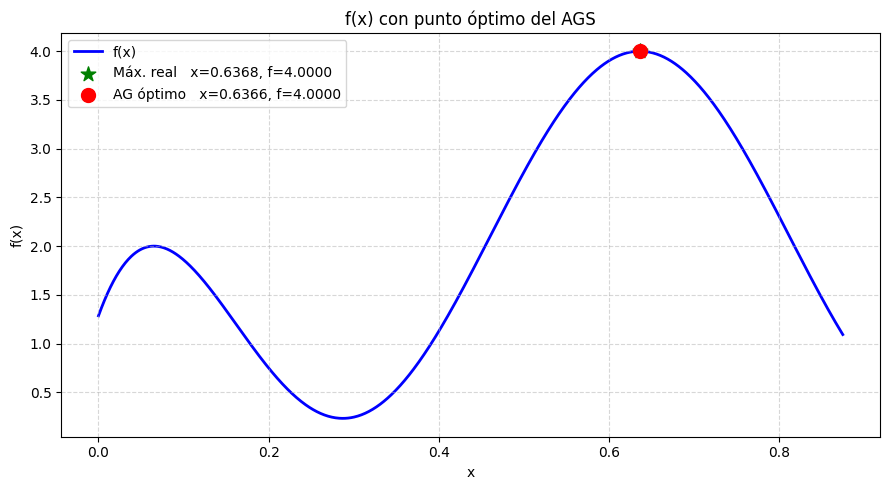


Comparación:
  Máximo real (fuerza bruta) : f=3.999988  en x=0.636762
  Máximo encontrado por AG   : f=3.999995  en x=0.636631
  Error relativo             : 0.0002%


In [10]:
x_plot = np.linspace(X_MIN, X_MAX, 1000)
y_plot = f(x_plot)

# Máximo real por fuerza bruta (referencia)
idx_bruto   = np.argmax(y_plot)
x_bruto_max = x_plot[idx_bruto]
y_bruto_max = y_plot[idx_bruto]

x_ag = hist_x[mejor_gen]
y_ag = hist_mejor[mejor_gen]

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)', zorder=1)
plt.scatter(x_bruto_max, y_bruto_max, color='green', s=120, zorder=5,
            label=f'Máx. real   x={x_bruto_max:.4f}, f={y_bruto_max:.4f}', marker='*')
plt.scatter(x_ag, y_ag, color='red', s=100, zorder=6,
            label=f'AG óptimo   x={x_ag:.4f}, f={y_ag:.4f}', marker='o')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) con punto óptimo del AGS')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'\nComparación:')
print(f'  Máximo real (fuerza bruta) : f={y_bruto_max:.6f}  en x={x_bruto_max:.6f}')
print(f'  Máximo encontrado por AG   : f={y_ag:.6f}  en x={x_ag:.6f}')
error = abs(y_bruto_max - y_ag) / abs(y_bruto_max) * 100
print(f'  Error relativo             : {error:.4f}%')